### 농구선수의 게임 데이터를 활용한 포지션 예측을 위한 데이터 정제

#### 문제정의
NBA 농구 선수들의 게임 기록을 데이터로 사용해서 특정 농구 선수의 포지션을 예측

In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("../Data/basketball.csv")
df.head()

,Player,Pos,3P,2P,TRB,AST,STL,BLK
0,Alex Abrines,SG,1.4,0.6,1.3,0.6,0.5,0.1
1,Steven Adams,C,0.0,4.7,7.7,1.1,1.1,1.0
2,Alexis Ajinca,C,0.0,2.3,4.5,0.3,0.5,0.6
3,Chris Andersen,C,0.0,0.8,2.6,0.4,0.4,0.6
4,Will Barton,SG,1.5,3.5,4.3,3.4,0.8,0.5


- Player : 선수 이름
- Pos : 포지션 (SG : Shooting Guard, C:Center)
- 3P : 한 경기당 평균 3점슛 성공 횟수
- 2P : 한 경기당 평균 2점슛 성공 횟수
- TRB : 한 경기당 평균 리바운드 성공 횟수
- AST : 한 경기당 평균 어시스트 성공 횟수
- STL : 한 경기당 평균 스틸 성공 횟수
- BLK : 한 경기당 평균 블로킹 성공 횟수

In [6]:
# 포지션의 종류 파악
df['Pos'].unique()

array(['SG', 'C'], dtype=object)

In [8]:
# 포지션별 갯수 파악
df.Pos.value_counts()


SG    50
C     50
Name: Pos, dtype: int64

### 포지션 별 내용
- C : 골데, 포스트 근처에서 슛을 블로킹하고 바깥으로 쳐내며 골대 근처에서 2점슛으로 득점 한다.
- SG : 코트내에서 3점슛 등 장거리에서 슛을 해서 점수를 얻는 역할

### 데이터 시각화
데이터를 특징을 바탕으로 한 공간에서 시각화 함으로써 머신러닝 학습에 필요한 특징과 불필요한 특징을 쉽게 구분

In [9]:
import matplotlib.pyplot as plt

In [10]:
# 한글 폰트 문제 해결 
# matplotlib은 한글 폰트를 지원하지 않음
# os정보
import platform

# font_manager : 폰트 관리 모듈
# rc : 폰트 변경 모듈
from matplotlib import font_manager, rc
# unicode 설정
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family='AppleGothic') # os가 macos
elif platform.system() == 'Windows':
    path = 'c:/Windows/Fonts/malgun.ttf' # os가 windows
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print("Unknown System")

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

/Users/tj/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


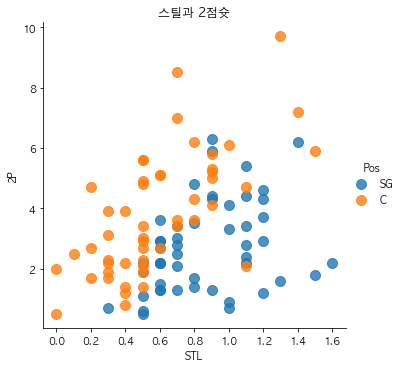

In [13]:
sns.lmplot(
    'STL',
    '2P',
    data=df,
    fit_reg=False,  # 회귀선 빼기
    scatter_kws={'s':100}, # 좌표상의 점의 크기
    hue = 'Pos' # 대상값
)
plt.title('스틸과 2점슛')
plt.show()